In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import warnings
from datetime import datetime
import joblib
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score,mean_squared_error

warnings.filterwarnings('ignore')

In [ ]:
df=pd.read_csv('final_internship_data.csv')
df.head()

,User ID,User Name,Driver Name,Car Condition,Weather,Traffic Condition,key,fare_amount,pickup_datetime,pickup_longitude,...,month,weekday,year,jfk_dist,ewr_dist,lga_dist,sol_dist,nyc_dist,distance,bearing
0,KHVrEVlD,Kimberly Adams,Amy Butler,Very Good,windy,Congested Traffic,2009-06-15 17:26:21.0000001,4.5,2009-06-15 17:26:21,-1.288826,...,6,0,2009,20.265840,55.176046,14.342611,34.543548,27.572573,1.030764,-2.918897
1,lPxIuEri,Justin Tapia,Hannah Zimmerman,Excellent,cloudy,Flow Traffic,2010-01-05 16:52:16.0000002,16.9,2010-01-05 16:52:16,-1.291824,...,1,1,2010,44.667679,31.832358,23.130775,15.125872,8.755732,8.450134,-0.375217
2,gsVN8JLS,Elizabeth Lopez,Amanda Jackson,Bad,stormy,Congested Traffic,2011-08-18 00:35:00.00000049,5.7,2011-08-18 00:35:00,-1.291242,...,8,3,2011,43.597686,33.712082,19.865289,17.722624,9.847344,1.389525,2.599961
3,9I7kWFgd,Steven Wilson,Amy Horn,Very Good,stormy,Flow Traffic,2012-04-21 04:30:42.0000001,7.7,2012-04-21 04:30:42,-1.291319,...,4,5,2012,42.642965,32.556289,21.063132,15.738963,7.703421,2.799270,0.133905
4,8QN5ZaGN,Alexander Andrews,Cassandra Larson,Bad,stormy,Congested Traffic,2010-03-09 07:51:00.000000135,5.3,2010-03-09 07:51:00,-1.290987,...,3,1,2010,43.329953,39.406828,15.219339,23.732406,15.600745,1.999157,-0.502703


In [ ]:
df.shape

(24574, 26)

In [ ]:
df = df.sample(n=5000, random_state=42) # Changed n to 5000, which is less than 6147

# Check the shape
print(df.shape)

(5000, 26)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5000 entries, 2350 to 18660
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   User ID            5000 non-null   object 
 1   User Name          5000 non-null   object 
 2   Driver Name        5000 non-null   object 
 3   Car Condition      5000 non-null   object 
 4   Weather            5000 non-null   object 
 5   Traffic Condition  5000 non-null   object 
 6   key                5000 non-null   object 
 7   fare_amount        5000 non-null   float64
 8   pickup_datetime    5000 non-null   object 
 9   pickup_longitude   5000 non-null   float64
 10  pickup_latitude    5000 non-null   float64
 11  dropoff_longitude  5000 non-null   float64
 12  dropoff_latitude   5000 non-null   float64
 13  passenger_count    5000 non-null   int64  
 14  hour               5000 non-null   int64  
 15  day                5000 non-null   int64  
 16  month              5000 n

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
fare_amount,5000.0,11.299500,9.405450,2.500000,6.000000,8.500000,12.500000,165.000000
pickup_longitude,5000.0,-1.268205,0.172894,-1.299192,-1.291403,-1.291222,-1.290970,0.711405
pickup_latitude,5000.0,0.698094,0.103606,-1.291401,0.710975,0.711271,0.711519,0.721975
dropoff_longitude,5000.0,-1.268224,0.172699,-1.294790,-1.291387,-1.291194,-1.290912,0.711405
dropoff_latitude,5000.0,0.698254,0.103133,-1.291446,0.710958,0.711291,0.711540,0.721975
passenger_count,5000.0,1.678600,1.306003,0.000000,1.000000,1.000000,2.000000,6.000000
hour,5000.0,13.512000,6.522788,0.000000,9.000000,14.000000,19.000000,23.000000
day,5000.0,15.625200,8.645674,1.000000,8.000000,16.000000,23.000000,31.000000
month,5000.0,6.256600,3.461669,1.000000,3.000000,6.000000,9.000000,12.000000
weekday,5000.0,3.017000,1.953324,0.000000,1.000000,3.000000,5.000000,6.000000


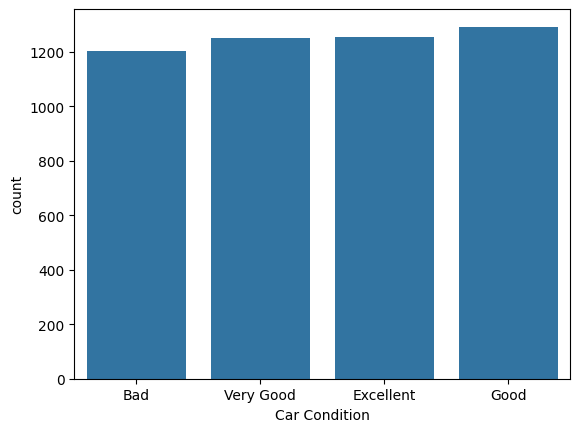

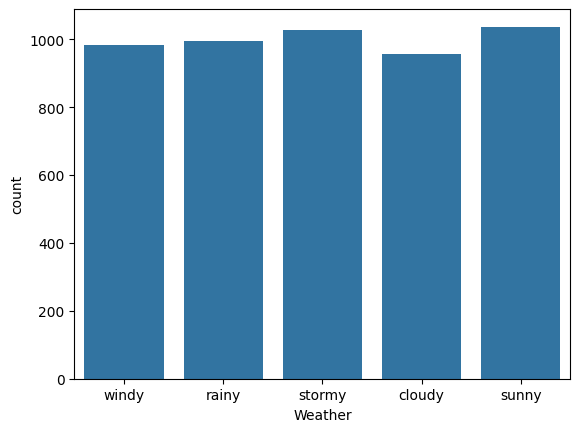

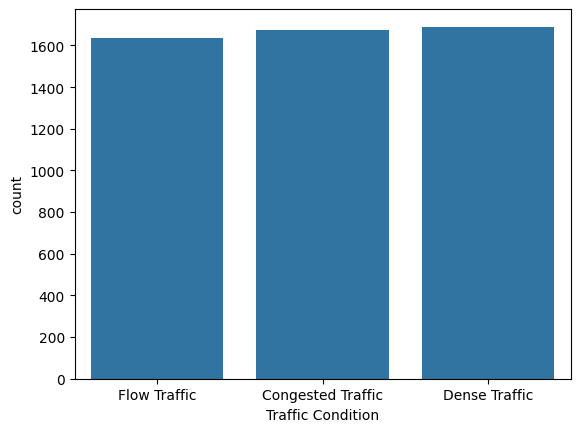

In [ ]:
sns.countplot(x="Car Condition", data=df); plt.show()
sns.countplot(x="Weather", data=df); plt.show()
sns.countplot(x="Traffic Condition", data=df); plt.show()

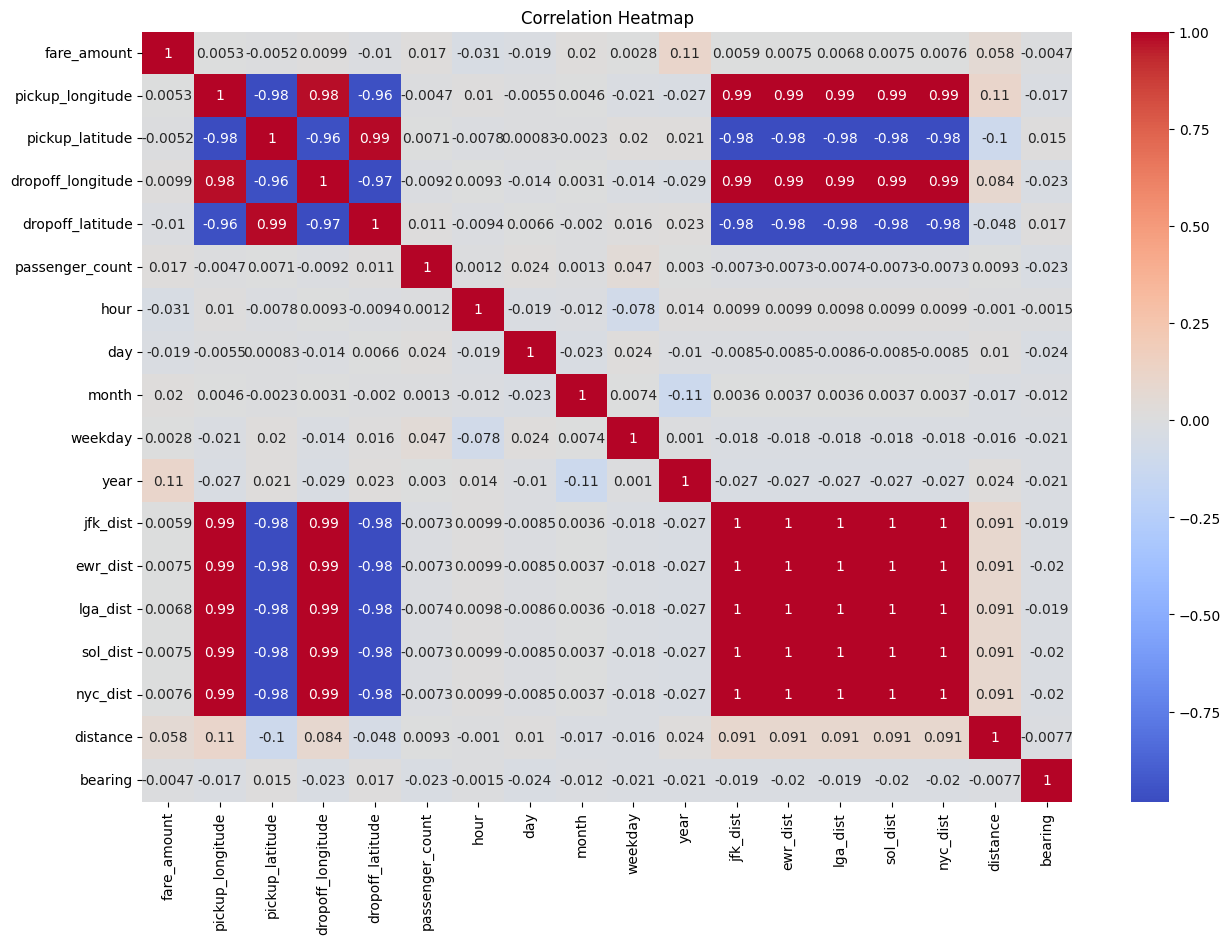

In [ ]:
plt.figure(figsize=(15,10))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
df.isnull().sum()

,0
User ID,0
User Name,0
Driver Name,0
Car Condition,0
Weather,0
Traffic Condition,0
key,0
fare_amount,0
pickup_datetime,0
pickup_longitude,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.drop(columns=['User ID', 'User Name', 'Driver Name','key','pickup_datetime','pickup_longitude','pickup_latitude','dropoff_longitude','dropoff_latitude'], inplace=True)


In [ ]:
import pandas as pd

# ------------------------
# 1) Ordinal Encoding for Car Condition
# ------------------------
ordinal_map = {
    'Bad': 1,
    'Very Good': 2,
    'Excellent': 3
}

df['Car Condition'] = df['Car Condition'].map(ordinal_map)

# ------------------------
# 2) One-Hot Encoding for Weather + Traffic Condition
# ------------------------
df = pd.get_dummies(df,
                    columns=['Weather', 'Traffic Condition'],
                    drop_first=True)


In [ ]:
dummy_cols = [col for col in df.columns if col.startswith('Weather_') or col.startswith('Traffic Condition_')]

# Convert these dummy columns from boolean (True/False) to integer (1/0)
df[dummy_cols] = df[dummy_cols].astype(int)

In [ ]:
df.columns

Index(['Car Condition', 'fare_amount', 'passenger_count', 'hour', 'day',
       'month', 'weekday', 'year', 'jfk_dist', 'ewr_dist', 'lga_dist',
       'sol_dist', 'nyc_dist', 'distance', 'bearing', 'Weather_rainy',
       'Weather_stormy', 'Weather_sunny', 'Weather_windy',
       'Traffic Condition_Dense Traffic', 'Traffic Condition_Flow Traffic'],
      dtype='object')

In [ ]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
print(numeric_cols)


Index(['Car Condition', 'fare_amount', 'passenger_count', 'hour', 'day',
       'month', 'weekday', 'year', 'jfk_dist', 'ewr_dist', 'lga_dist',
       'sol_dist', 'nyc_dist', 'distance', 'bearing', 'Weather_rainy',
       'Weather_stormy', 'Weather_sunny', 'Weather_windy',
       'Traffic Condition_Dense Traffic', 'Traffic Condition_Flow Traffic'],
      dtype='object')


Shape after removing outliers (IQR): (3527, 21)


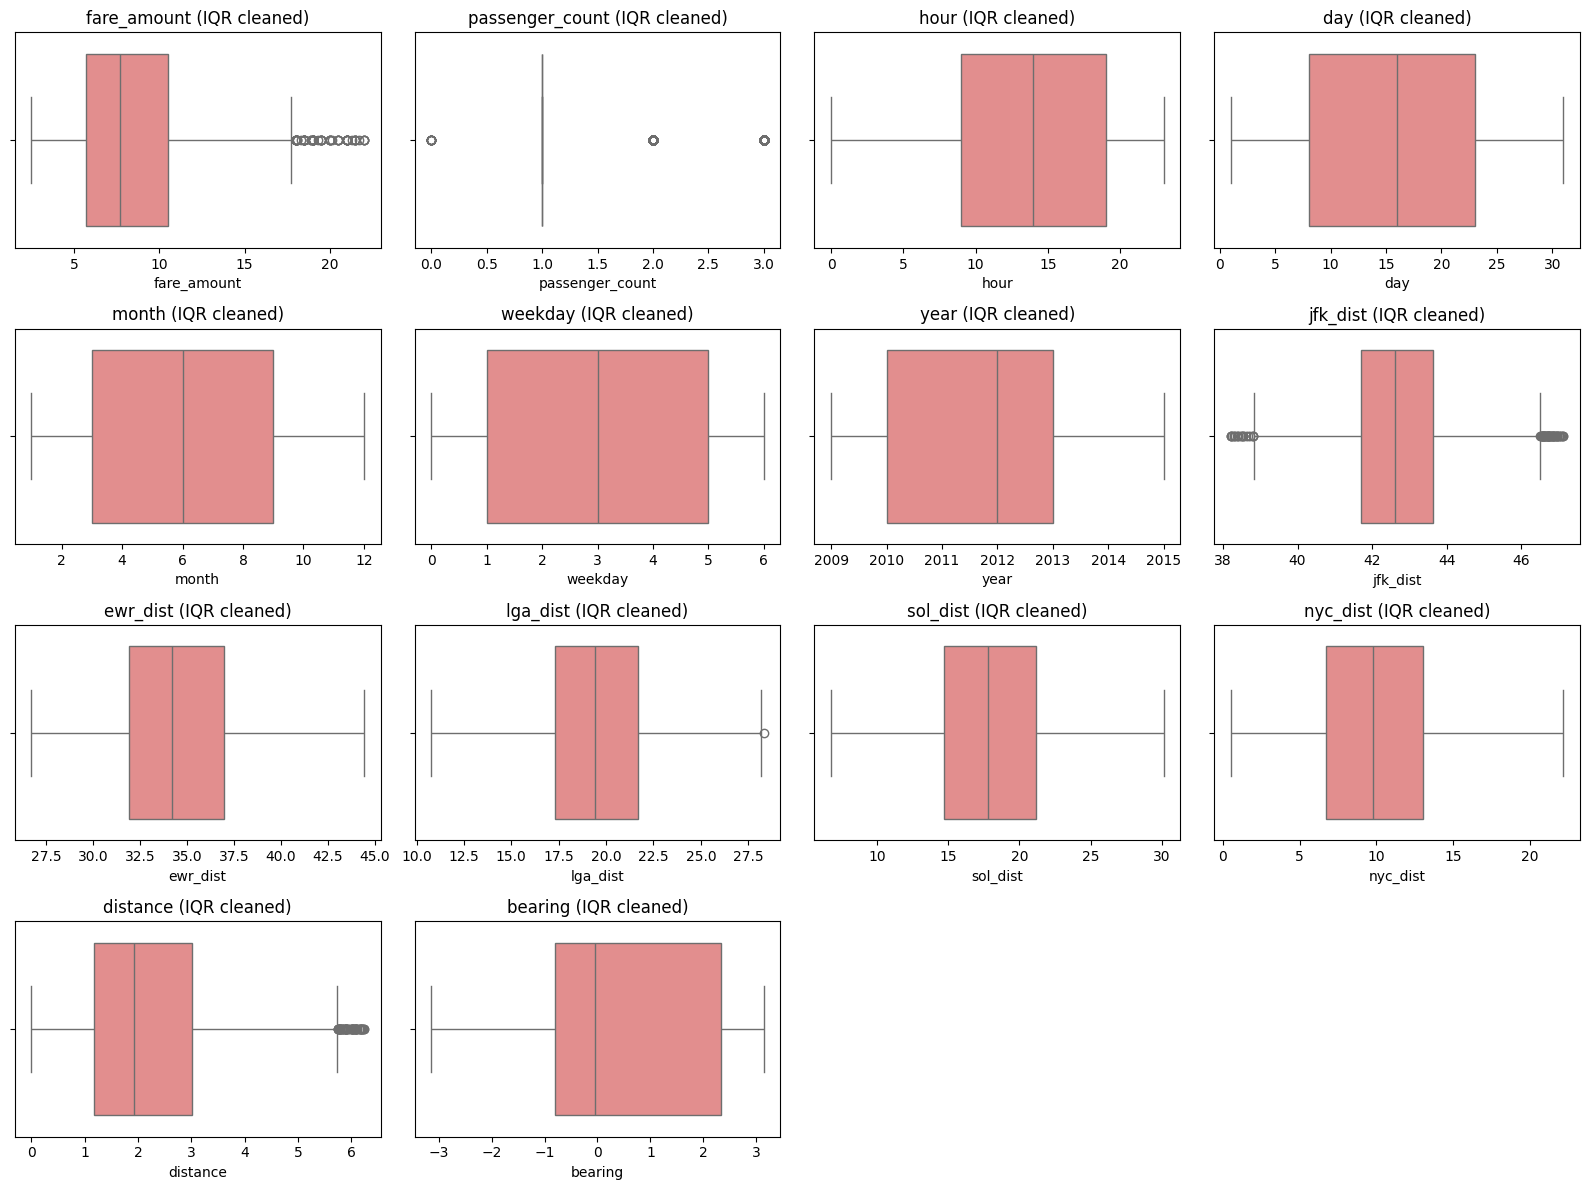

In [ ]:
numeric_cols = ['fare_amount','passenger_count', 'hour', 'day', 'month', 'weekday', 'year',
                'jfk_dist', 'ewr_dist', 'lga_dist', 'sol_dist', 'nyc_dist',
                'distance', 'bearing']


df_iqr = df.copy()
for col in numeric_cols:
    Q1 = df_iqr[col].quantile(0.25)
    Q3 = df_iqr[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_iqr = df_iqr[(df_iqr[col] >= lower_bound) & (df_iqr[col] <= upper_bound) | (df_iqr[col].isna())]
print("Shape after removing outliers (IQR):", df_iqr.shape)

# Calculate optimal grid size for subplots
num_plots = len(numeric_cols)
num_cols_per_row = 4 # You can adjust this number
num_rows = (num_plots + num_cols_per_row - 1) // num_cols_per_row # Ceiling division

plt.figure(figsize=(num_cols_per_row * 4, num_rows * 3)) # Adjust figure size dynamically
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(num_rows, num_cols_per_row, i)
    sns.boxplot(x=df_iqr[col], color="lightcoral")
    plt.title(f'{col} (IQR cleaned)')
plt.tight_layout(); plt.show()

In [ ]:

print(df.dtypes)


categorical_cols = df.select_dtypes(include=['object']).columns
print("Categorical columns:", categorical_cols)


Car Condition                      float64
fare_amount                        float64
passenger_count                      int64
hour                                 int64
day                                  int64
month                                int64
weekday                              int64
year                                 int64
jfk_dist                           float64
ewr_dist                           float64
lga_dist                           float64
sol_dist                           float64
nyc_dist                           float64
distance                           float64
bearing                            float64
Weather_rainy                        int64
Weather_stormy                       int64
Weather_sunny                        int64
Weather_windy                        int64
Traffic Condition_Dense Traffic      int64
Traffic Condition_Flow Traffic       int64
dtype: object
Categorical columns: Index([], dtype='object')


In [ ]:
for col in categorical_cols:
    df[col] = df[col].astype('category')


print(df.dtypes)


Car Condition                      float64
fare_amount                        float64
passenger_count                      int64
hour                                 int64
day                                  int64
month                                int64
weekday                              int64
year                                 int64
jfk_dist                           float64
ewr_dist                           float64
lga_dist                           float64
sol_dist                           float64
nyc_dist                           float64
distance                           float64
bearing                            float64
Weather_rainy                        int64
Weather_stormy                       int64
Weather_sunny                        int64
Weather_windy                        int64
Traffic Condition_Dense Traffic      int64
Traffic Condition_Flow Traffic       int64
dtype: object


In [ ]:
for col in categorical_cols:
    print(f"Unique values in '{col}': {df[col].unique()}")

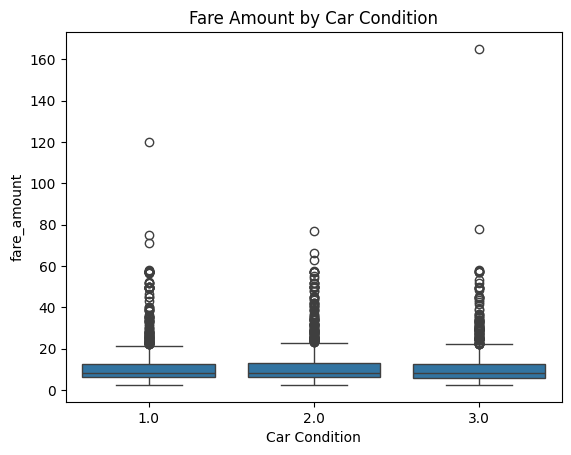

In [ ]:
sns.boxplot(x="Car Condition", y="fare_amount", data=df)
plt.title("Fare Amount by Car Condition")
plt.show()

In [ ]:
import pandas as pd

numeric_cols = ['fare_amount','passenger_count', 'hour', 'day', 'month', 'weekday', 'year',
                'jfk_dist', 'ewr_dist', 'lga_dist', 'sol_dist', 'nyc_dist',
                'distance', 'bearing']
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)
df[numeric_cols].describe()


,fare_amount,passenger_count,hour,day,month,weekday,year,jfk_dist,ewr_dist,lga_dist,sol_dist,nyc_dist,distance,bearing
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,10.136254,1.509200,13.512000,15.625200,6.256600,3.017000,2011.739200,42.449160,35.703057,19.605485,19.082482,11.275359,2.893791,0.317340
std,5.448333,0.874167,6.522788,8.645674,3.461669,1.953324,1.867908,2.361644,4.751944,4.017738,5.664305,5.513087,2.237105,1.794841
min,2.500000,0.000000,0.000000,1.000000,1.000000,0.000000,2009.000000,37.652451,23.189822,9.692762,5.415659,0.526054,0.000000,-3.140087
25%,6.000000,1.000000,9.000000,8.000000,3.000000,1.000000,2010.000000,41.316596,32.259989,17.105966,14.988847,7.265941,1.231995,-0.817475
50%,8.500000,1.000000,14.000000,16.000000,6.000000,3.000000,2012.000000,42.518254,34.793879,19.511876,18.336704,10.473114,2.183747,-0.054627
75%,12.500000,2.000000,19.000000,23.000000,9.000000,5.000000,2013.000000,43.759359,38.306768,22.048102,22.376462,14.414070,3.938218,2.203382
max,22.250000,3.500000,23.000000,31.000000,12.000000,6.000000,2015.000000,47.423504,47.376935,29.461306,33.457884,25.136264,7.997551,3.141593


In [ ]:
df.columns


Index(['Car Condition', 'fare_amount', 'passenger_count', 'hour', 'day',
       'month', 'weekday', 'year', 'jfk_dist', 'ewr_dist', 'lga_dist',
       'sol_dist', 'nyc_dist', 'distance', 'bearing', 'Weather_rainy',
       'Weather_stormy', 'Weather_sunny', 'Weather_windy',
       'Traffic Condition_Dense Traffic', 'Traffic Condition_Flow Traffic'],
      dtype='object')

In [ ]:
df.head()

,Car Condition,fare_amount,passenger_count,hour,day,month,weekday,year,jfk_dist,ewr_dist,...,sol_dist,nyc_dist,distance,bearing,Weather_rainy,Weather_stormy,Weather_sunny,Weather_windy,Traffic Condition_Dense Traffic,Traffic Condition_Flow Traffic
2350,1.0,8.1,1.0,19,9,7,3,2009,45.543503,36.247755,...,21.499691,13.828102,3.219054,-0.331162,0,0,0,1,0,1
23249,2.0,7.0,1.0,10,5,7,4,2013,42.606798,39.050803,...,23.036820,14.838073,1.744387,2.396908,0,0,0,1,0,0
11000,1.0,8.9,1.0,23,12,8,4,2011,46.225256,36.882181,...,22.509502,14.967497,4.033007,2.498536,0,0,0,1,0,1
13627,3.0,10.0,1.0,22,30,9,6,2012,37.652451,38.800786,...,20.307561,11.838438,0.000000,0.000000,1,0,0,0,0,0
21894,1.0,10.0,3.5,5,13,2,4,2015,41.012473,32.207407,...,14.102081,5.682577,3.605675,2.511131,0,1,0,0,0,1


In [ ]:
# The original 'Weather' and 'Traffic Condition' columns were converted into dummy variables
# using one-hot encoding, and the 'Car Condition' column was ordinal encoded into numerical values.
# Therefore, these columns no longer exist in their original categorical form.
# As there are no remaining object-type categorical columns to process for rare labels,
# the list of categorical columns for this operation should be empty.
categorical_cols = []

for col in categorical_cols:

    freq = df[col].value_counts(normalize=True)
    rare_labels = freq[freq < 0.01].index


    df[col] = df[col].replace(rare_labels, df[col].mode()[0])

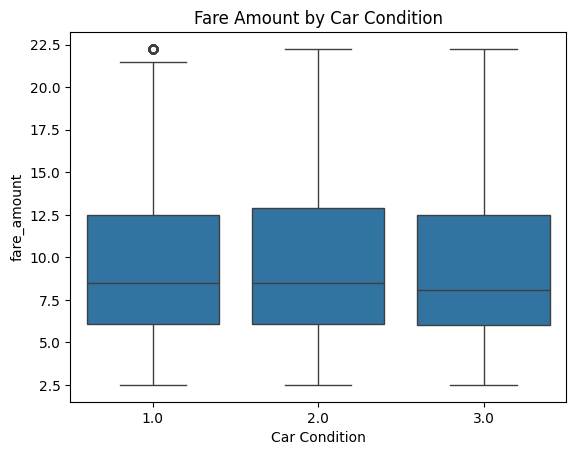

In [ ]:
sns.boxplot(x="Car Condition", y="fare_amount", data=df)
plt.title("Fare Amount by Car Condition")
plt.show()

In [ ]:
from scipy.stats import skew

skewness = skew(df['fare_amount'])
print("Skewness:", skewness)


Skewness: 1.0150609592337243


In [ ]:
from scipy.stats import skew

skewness = skew(df['fare_amount'])
print("Skewness:", skewness)


Skewness: 1.0150609592337243


In [ ]:
df['fare_log'] = np.log1p(df['fare_amount'])
skew(df['fare_log'])


np.float64(0.29383098016537634)

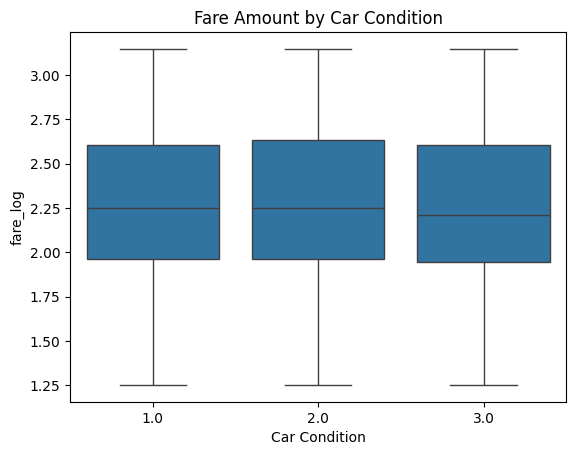

In [ ]:
sns.boxplot(x="Car Condition", y="fare_log", data=df)
plt.title("Fare Amount by Car Condition")
plt.show()

In [ ]:
print("Before log:", skew(df['fare_amount']))
print("After log:", skew(df['fare_log']))


Before log: 1.0150609592337243
After log: 0.29383098016537634


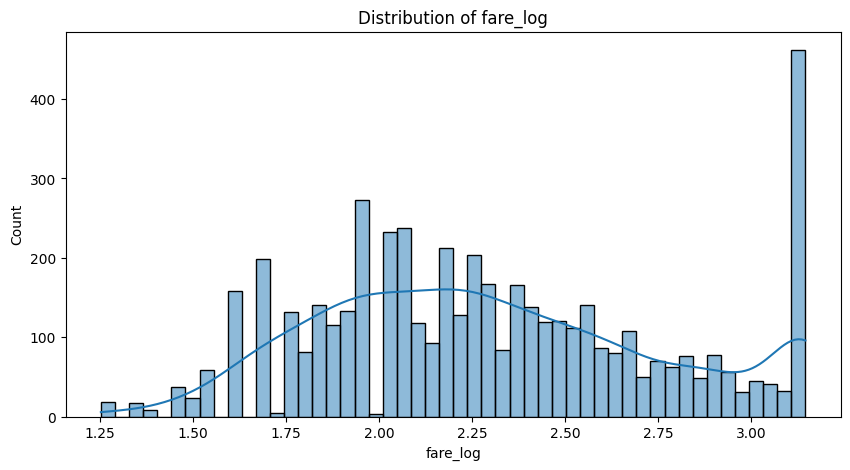

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(df['fare_log'], bins=50, kde=True)
plt.title("Distribution of fare_log")
plt.show()


In [ ]:
df.isnull().sum()

,0
Car Condition,1292
fare_amount,0
passenger_count,0
hour,0
day,0
month,0
weekday,0
year,0
jfk_dist,0
ewr_dist,0


In [ ]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')
X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

In [ ]:
Q1 = df['fare_log'].quantile(0.25)
Q3 = df['fare_log'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df['fare_log'] = df['fare_log'].clip(lower, upper)

In [ ]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='most_frequent')
df['Car Condition'] = imputer.fit_transform(df[['Car Condition']])

In [ ]:
df.isnull().sum()

,0
Car Condition,0
fare_amount,0
passenger_count,0
hour,0
day,0
month,0
weekday,0
year,0
jfk_dist,0
ewr_dist,0


In [ ]:
X = df.drop(columns=['fare_amount', 'fare_log'])
y = df['fare_log']

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train_scaled, y_train)

LinearRegression()

In [ ]:
y_pred_log = model.predict(X_test_scaled)

In [ ]:
import numpy as np
y_pred_amount = np.exp(y_pred_log)
y_test_amount = np.exp(y_test)

In [ ]:
df['fare_amount'].describe()

,fare_amount
count,5000.000000
mean,10.136254
std,5.448333
min,2.500000
25%,6.000000
50%,8.500000
75%,12.500000
max,22.250000


In [ ]:
y_pred = model.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

Mean Absolute Error (MAE): 0.18
Root Mean Squared Error (RMSE): 0.25
R² Score: 0.7024


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np


In [ ]:
X = df.drop(columns=['fare_amount', 'fare_log'])
y = df['fare_log']

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
model = ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=42)
model.fit(X_train_scaled, y_train)

ElasticNet(alpha=0.1, random_state=42)

In [ ]:
y_pred = model.predict(X_test_scaled)

In [ ]:
y_pred = model.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

Mean Absolute Error (MAE): 0.20
Root Mean Squared Error (RMSE): 0.27
R² Score: 0.6579
